# Installing the dependencies

In [ ]:
! pip install xgboost
! pip install lightgbm
! pip install catboost
! pip install shap
! pip install fastapi uvicorn


[notice] A new release of pip is available: 26.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
   ------- -------------------------------- 0.3/1.5 MB ? eta -:--:--
   -------------- ------------------------- 0.5/1.5 MB 2.1 MB/s eta 0:00:01
   ---------------------------- ----------- 1.0/1.5 MB 1.9 MB/s eta 0:00:01
   ------------------------------------ --- 1.3/1.5 MB 1.8 MB/s eta 0:00:01
   ---------------------------------------- 1.5/1.5 MB 1.7 MB/s  0:00:00



[notice] A new release of pip is available: 26.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


   ---------------------------------------- 0.0/100.2 MB ? eta -:--:--
   ---------------------------------------- 0.3/100.2 MB ? eta -:--:--
   ---------------------------------------- 0.8/100.2 MB 2.1 MB/s eta 0:00:48
   ---------------------------------------- 1.0/100.2 MB 2.1 MB/s eta 0:00:48
    --------------------------------------- 1.6/100.2 MB 1.9 MB/s eta 0:00:52
    --------------------------------------- 1.8/100.2 MB 1.9 MB/s eta 0:00:51
    --------------------------------------- 2.4/100.2 MB 2.0 MB/s eta 0:00:50
   - -------------------------------------- 2.6/100.2 MB 1.9 MB/s eta 0:00:51
   - -------------------------------------- 2.9/100.2 MB 1.9 MB/s eta 0:00:51
   - -------------------------------------- 3.1/100.2 MB 1.9 MB/s eta 0:00:52
   - -------------------------------------- 3.4/100.2 MB 1.8 MB/s eta 0:00:54
   - -------------------------------------- 3.7/100.2 MB 1.7 MB/s eta 0:00:57
   - -------------------------------------- 3.9/100.2 MB 1.7 MB/s eta 0:00:59



[notice] A new release of pip is available: 26.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [135]:
! pip install shap

   ---------------------------------------- 0.0/556.1 kB ? eta -:--:--
   ------------------ --------------------- 262.1/556.1 kB ? eta -:--:--
   ---------------------------------------- 556.1/556.1 kB 2.4 MB/s  0:00:00
   ---------------------------------------- 0.0/38.1 MB ? eta -:--:--
   ---------------------------------------- 0.3/38.1 MB ? eta -:--:--
    --------------------------------------- 0.8/38.1 MB 2.2 MB/s eta 0:00:17
   - -------------------------------------- 1.3/38.1 MB 2.3 MB/s eta 0:00:16
   - -------------------------------------- 1.6/38.1 MB 2.3 MB/s eta 0:00:17
   -- ------------------------------------- 2.4/38.1 MB 2.5 MB/s eta 0:00:15
   --- ------------------------------------ 2.9/38.1 MB 2.5 MB/s eta 0:00:14
   --- ------------------------------------ 3.4/38.1 MB 2.5 MB/s eta 0:00:14
   --- ------------------------------------ 3.7/38.1 MB 2.4 MB/s eta 0:00:15
   ---- ----------------------------------- 4.2/38.1 MB 2.4 MB/s eta 0:00:15
   ---- ---------------


[notice] A new release of pip is available: 26.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


# Importing the Dependencies

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

# HYPERPARAMETER TUNING LIBRARIES

from sklearn.model_selection import (
    RandomizedSearchCV
)

from lightgbm import LGBMClassifier

from sklearn.metrics import (
    roc_auc_score
)

import numpy as np


# ENSEMBLE LEARNING LIBRARY

from sklearn.ensemble import VotingClassifier


# SHAP LIBRARIES

import shap




# Loading the csv file


In [ ]:
df = pd.read_csv(r"D:/Landslide_susceptibility_model/notebooks/final_training_dataset.csv")

## Data Handling 

In [3]:
print(df.shape)
print(df.info())

(3000, 36)
<class 'pandas.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 36 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Latitude                3000 non-null   float64
 1   Longitude               3000 non-null   float64
 2   Rain_Mean               3000 non-null   float64
 3   Rain_Max                3000 non-null   float64
 4   Rain_STD                3000 non-null   float64
 5   Landslide               3000 non-null   int64  
 6   dist_to_rivers          2971 non-null   float64
 7   dist_to_roads           84 non-null     float64
 8   dist_to_streams         174 non-null    float64
 9   dominant_lulc           3000 non-null   int64  
 10  litho_clay              3000 non-null   float64
 11  litho_iron_oxide        3000 non-null   float64
 12  lulc_change_frequency   3000 non-null   int64  
 13  lulc_stability          3000 non-null   float64
 14  moisture_features       3000 non-null   

In [4]:
## checking for missing values 

print(df.isnull().sum())
print("Number of duplicates:", df.duplicated().sum())

Latitude                     0
Longitude                    0
Rain_Mean                    0
Rain_Max                     0
Rain_STD                     0
Landslide                    0
dist_to_rivers              29
dist_to_roads             2916
dist_to_streams           2826
dominant_lulc                0
litho_clay                   0
litho_iron_oxide             0
lulc_change_frequency        0
lulc_stability               0
moisture_features            0
moisture_pca                 0
ndvi_monsoon_mean            0
ndvi_pre_mean                0
ndvi_std                     0
soil_bulk_density            0
soil_clay_content_pct        0
soil_organic_carbon          0
soil_sand_content_pct        0
soil_texture_0cm             0
terrain_aspect              35
terrain_aspect_cos          35
terrain_aspect_sin          35
terrain_elevation            0
terrain_hillshade            0
terrain_roughness            0
terrain_slope               35
terrain_slope_radians       35
terrain_

In [5]:
## Checking the statistics of the dataset
print(df.describe())

          Latitude    Longitude    Rain_Mean     Rain_Max     Rain_STD  \
count  3000.000000  3000.000000  3000.000000  3000.000000  3000.000000   
mean     24.713321    92.965590     5.272601   149.661557    11.154040   
std       0.650835     0.207677     1.206367    39.668753     2.238597   
min      23.500378    91.145280     3.019148    81.077750     7.351669   
25%      24.152051    92.797517     4.266902   114.184051     8.912325   
50%      24.794173    92.973947     5.337398   162.433960    10.931809   
75%      25.237050    93.125556     6.313474   179.593445    13.098291   
max      26.202610    94.760000     7.975453   318.985657    17.160574   

         Landslide  dist_to_rivers  dist_to_roads  dist_to_streams  \
count  3000.000000     2971.000000           84.0            174.0   
mean      0.111333      701.882129            0.0              0.0   
std       0.314597      534.793908            0.0              0.0   
min       0.000000        0.000000            0.0    

In [55]:
## Removing the columns with missing values

df_clean = df.drop(columns=['dist_to_roads','dist_to_streams', 'label','terrain_slope_radians','litho_iron_oxide'])

df_clean.info()

<class 'pandas.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 31 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Latitude                3000 non-null   float64
 1   Longitude               3000 non-null   float64
 2   Rain_Mean               3000 non-null   float64
 3   Rain_Max                3000 non-null   float64
 4   Rain_STD                3000 non-null   float64
 5   Landslide               3000 non-null   int64  
 6   dist_to_rivers          2971 non-null   float64
 7   dominant_lulc           3000 non-null   int64  
 8   litho_clay              3000 non-null   float64
 9   lulc_change_frequency   3000 non-null   int64  
 10  lulc_stability          3000 non-null   float64
 11  moisture_features       3000 non-null   float64
 12  moisture_pca            3000 non-null   float64
 13  ndvi_monsoon_mean       3000 non-null   float64
 14  ndvi_pre_mean           3000 non-null   float64
 15

In [56]:
# Checking for missing values in the cleaned dataset.

print(df_clean.isnull().sum())

Latitude                   0
Longitude                  0
Rain_Mean                  0
Rain_Max                   0
Rain_STD                   0
Landslide                  0
dist_to_rivers            29
dominant_lulc              0
litho_clay                 0
lulc_change_frequency      0
lulc_stability             0
moisture_features          0
moisture_pca               0
ndvi_monsoon_mean          0
ndvi_pre_mean              0
ndvi_std                   0
soil_bulk_density          0
soil_clay_content_pct      0
soil_organic_carbon        0
soil_sand_content_pct      0
soil_texture_0cm           0
terrain_aspect            35
terrain_aspect_cos        35
terrain_aspect_sin        35
terrain_elevation          0
terrain_hillshade          0
terrain_roughness          0
terrain_slope             35
terrain_tpi               29
twi                       35
vegetation_persistence     0
dtype: int64


In [57]:
# SUSPICIOUS ZERO ANALYSIS
# Checking for abnormal zero values in the dataset


zero_counts = (df_clean == 0).sum()

zero_percent = ((df_clean == 0).sum() / len(df_clean)) * 100

zero_df = pd.DataFrame({
    'Zero_Count': zero_counts,
    'Zero_Percent': zero_percent
})

print(
    zero_df.sort_values(
        by='Zero_Percent',
        ascending=False
    )
)

                        Zero_Count  Zero_Percent
lulc_change_frequency         2863     95.433333
Landslide                     2666     88.866667
vegetation_persistence        1878     62.600000
dominant_lulc                 1853     61.766667
lulc_stability                1847     61.566667
ndvi_monsoon_mean             1847     61.566667
litho_clay                    1847     61.566667
ndvi_pre_mean                 1847     61.566667
ndvi_std                      1846     61.533333
terrain_aspect                 158      5.266667
terrain_aspect_sin             158      5.266667
terrain_hillshade              119      3.966667
soil_bulk_density              118      3.933333
soil_organic_carbon            118      3.933333
soil_clay_content_pct          118      3.933333
soil_sand_content_pct          118      3.933333
soil_texture_0cm               118      3.933333
dist_to_rivers                 116      3.866667
terrain_roughness              114      3.800000
terrain_elevation   

In [58]:
# Checking the distribution of the NDVI features

print(df_clean[['ndvi_pre_mean',
                'ndvi_monsoon_mean',
                'ndvi_std']].describe())

       ndvi_pre_mean  ndvi_monsoon_mean     ndvi_std
count    3000.000000        3000.000000  3000.000000
mean        0.185032           0.253548     0.115761
std         0.242592           0.328343     2.282853
min         0.000000           0.000000     0.000000
25%         0.000000           0.000000     0.000000
50%         0.000000           0.000000     0.000000
75%         0.451798           0.634324     0.179032
max         0.689730           0.846446   125.000000


In [59]:
# NDVI_STD OUTLIER CLEANING
# Replace unrealistic values (>1)


df_clean.loc[
    df_clean['ndvi_std'] > 1,
    'ndvi_std'
] = np.nan

# Fill using median

df_clean['ndvi_std'] = df_clean['ndvi_std'].fillna(
    df_clean['ndvi_std'].median()
)

# Verify
print(df_clean['ndvi_std'].describe())

count    3000.000000
mean        0.074094
std         0.096240
min         0.000000
25%         0.000000
50%         0.000000
75%         0.178935
max         0.438231
Name: ndvi_std, dtype: float64


In [60]:
# Checking the distribution of the NDVI features

print(df_clean[['ndvi_pre_mean',
                'ndvi_monsoon_mean',
                'ndvi_std']].describe())

       ndvi_pre_mean  ndvi_monsoon_mean     ndvi_std
count    3000.000000        3000.000000  3000.000000
mean        0.185032           0.253548     0.074094
std         0.242592           0.328343     0.096240
min         0.000000           0.000000     0.000000
25%         0.000000           0.000000     0.000000
50%         0.000000           0.000000     0.000000
75%         0.451798           0.634324     0.178935
max         0.689730           0.846446     0.438231



Filling the missing values 

In [61]:
# Check number of zero values
zero_count = (df_clean['terrain_elevation'] == 0).sum()

print("Zero Values in terrain_elevation :", zero_count)

# Replace zeros with NaN
df_clean['terrain_elevation'] = df_clean['terrain_elevation'].replace(0, np.nan)

# Fill NaN values with median
median_value = df_clean['terrain_elevation'].median()

df_clean['terrain_elevation'] = df_clean['terrain_elevation'].fillna(median_value)

# Verify again
print("Remaining Zero Values :",
      (df_clean['terrain_elevation'] == 0).sum())

print("Remaining Missing Values :",
      df_clean['terrain_elevation'].isnull().sum())

Zero Values in terrain_elevation : 113
Remaining Zero Values : 0
Remaining Missing Values : 0


In [86]:
import numpy as np

# =========================================
# DISTANCE TO RIVERS
# Median Imputation
# =========================================

# Replace suspicious zeros with NaN
df_clean['dist_to_rivers'] = df_clean['dist_to_rivers'].replace(0, np.nan)

# Fill missing values using median
df_clean['dist_to_rivers'] = (
    df_clean['dist_to_rivers']
    .fillna(
        df_clean['dist_to_rivers'].median()
    )
)

# =========================================
# TERRAIN ASPECT
# Mode Imputation
# =========================================

df_clean['terrain_aspect'] = (
    df_clean['terrain_aspect']
    .fillna(
        df_clean['terrain_aspect'].mode()[0]
    )
)

# =========================================
# TERRAIN ASPECT COS
# Median Imputation
# =========================================

df_clean['terrain_aspect_cos'] = (
    df_clean['terrain_aspect_cos']
    .fillna(
        df_clean['terrain_aspect_cos'].median()
    )
)

# =========================================
# TERRAIN ASPECT SIN
# Median Imputation
# =========================================

df_clean['terrain_aspect_sin'] = (
    df_clean['terrain_aspect_sin']
    .fillna(
        df_clean['terrain_aspect_sin'].median()
    )
)

# =========================================
# TERRAIN TPI
# Median Imputation
# =========================================

# Replace suspicious zeros with NaN
df_clean['terrain_tpi'] = (
    df_clean['terrain_tpi']
    .replace(0, np.nan)
)

# Fill missing values using median
df_clean['terrain_tpi'] = (
    df_clean['terrain_tpi']
    .fillna(
        df_clean['terrain_tpi'].median()
    )
)

# =========================================
# TWI
# Median Imputation
# =========================================

# Replace suspicious zeros with NaN
df_clean['twi'] = (
    df_clean['twi']
    .replace(0, np.nan)
)

# Fill missing values using median
df_clean['twi'] = (
    df_clean['twi']
    .fillna(
        df_clean['twi'].median()
    )
)

# =========================================
# FINAL VERIFICATION
# =========================================

print("Remaining Missing Values :\\n")

print(
    df_clean[
        [
            'dist_to_rivers',
            'terrain_aspect',
            'terrain_aspect_cos',
            'terrain_aspect_sin',
            'terrain_tpi',
            'twi'
        ]
    ].isnull().sum()
)

Remaining Missing Values :\n
dist_to_rivers        0
terrain_aspect        0
terrain_aspect_cos    0
terrain_aspect_sin    0
terrain_tpi           0
twi                   0
dtype: int64


In [62]:
# Check missing and zero values
print("Missing Values :",
      df_clean['terrain_slope'].isnull().sum())

print("Zero Values :",
      (df_clean['terrain_slope'] == 0).sum())

# Replace suspicious zeros with NaN
df_clean['terrain_slope'] = df_clean['terrain_slope'].replace(0, np.nan)

# Fill using median
median_value = df_clean['terrain_slope'].median()

df_clean['terrain_slope'] = df_clean['terrain_slope'].fillna(median_value)

# Verify
print("After Filling")
print("Missing Values :",
      df_clean['terrain_slope'].isnull().sum())
print("Zero Values :",
      (df_clean['terrain_slope'] == 0).sum())


Missing Values : 35
Zero Values : 103
After Filling
Missing Values : 0
Zero Values : 0


In [63]:
# checking the data 
df_clean.info()

<class 'pandas.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 31 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Latitude                3000 non-null   float64
 1   Longitude               3000 non-null   float64
 2   Rain_Mean               3000 non-null   float64
 3   Rain_Max                3000 non-null   float64
 4   Rain_STD                3000 non-null   float64
 5   Landslide               3000 non-null   int64  
 6   dist_to_rivers          2971 non-null   float64
 7   dominant_lulc           3000 non-null   int64  
 8   litho_clay              3000 non-null   float64
 9   lulc_change_frequency   3000 non-null   int64  
 10  lulc_stability          3000 non-null   float64
 11  moisture_features       3000 non-null   float64
 12  moisture_pca            3000 non-null   float64
 13  ndvi_monsoon_mean       3000 non-null   float64
 14  ndvi_pre_mean           3000 non-null   float64
 15

## EDA of Clean Data 

In [64]:
print(df_clean.shape)
print(df_clean.info())
print(df_clean.describe())

(3000, 31)
<class 'pandas.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 31 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Latitude                3000 non-null   float64
 1   Longitude               3000 non-null   float64
 2   Rain_Mean               3000 non-null   float64
 3   Rain_Max                3000 non-null   float64
 4   Rain_STD                3000 non-null   float64
 5   Landslide               3000 non-null   int64  
 6   dist_to_rivers          2971 non-null   float64
 7   dominant_lulc           3000 non-null   int64  
 8   litho_clay              3000 non-null   float64
 9   lulc_change_frequency   3000 non-null   int64  
 10  lulc_stability          3000 non-null   float64
 11  moisture_features       3000 non-null   float64
 12  moisture_pca            3000 non-null   float64
 13  ndvi_monsoon_mean       3000 non-null   float64
 14  ndvi_pre_mean           3000 non-null   

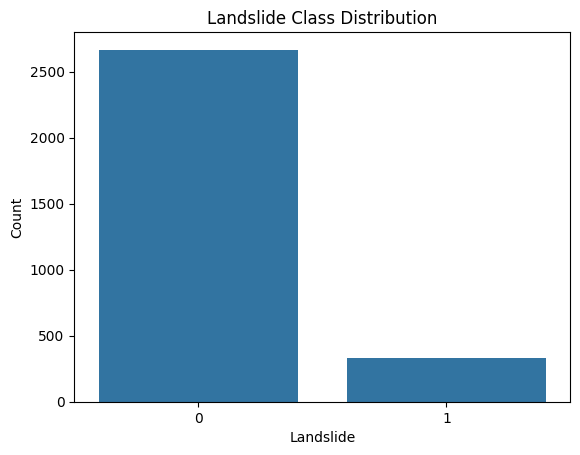

'\n1. the dataset is imbalnced with more non-landslide samples.\n\n'

In [65]:
# Checking the class distribution of the target variable
# landslide is the target variable.

sns.countplot(x=df_clean['Landslide'])

plt.title("Landslide Class Distribution")
plt.xlabel("Landslide")
plt.ylabel("Count")

plt.show()

'''
1. the dataset is imbalnced with more non-landslide samples.

'''

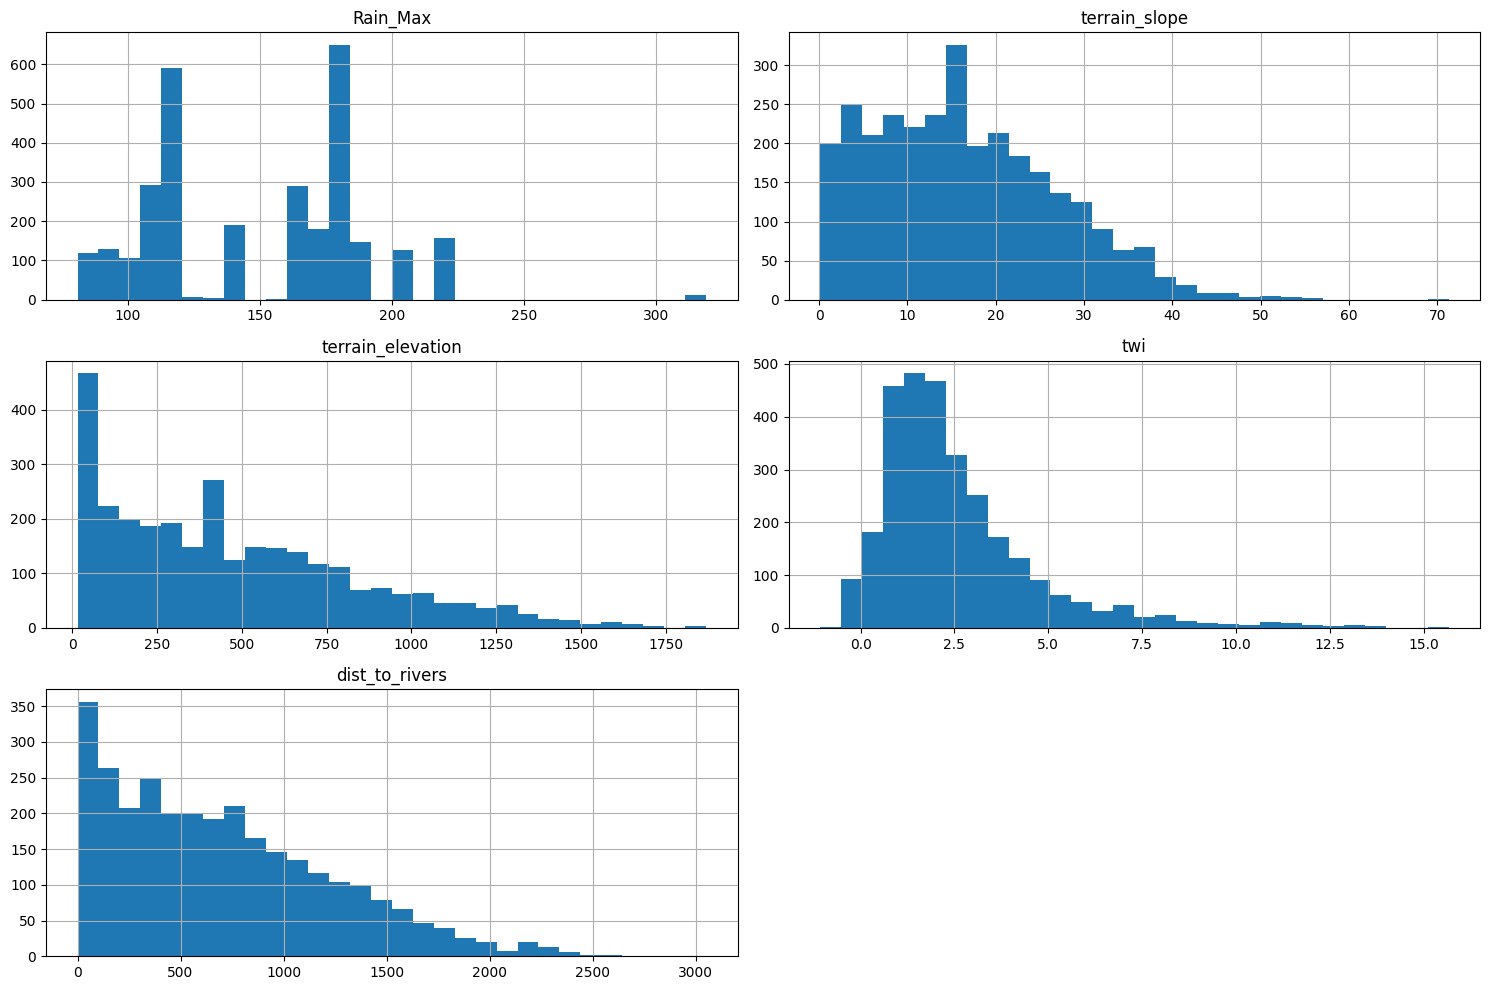

In [66]:
## FEATURE DISTRIBUTION PLOTS

# Chossen important features based on domain knowledge and correlation analysis.


important_cols = [
    'Rain_Max',
    'terrain_slope',
    'terrain_elevation',
    'twi',
    'dist_to_rivers'
]

df_clean[important_cols].hist(
    figsize=(15,10),
    bins=30
)

plt.tight_layout()
plt.show()

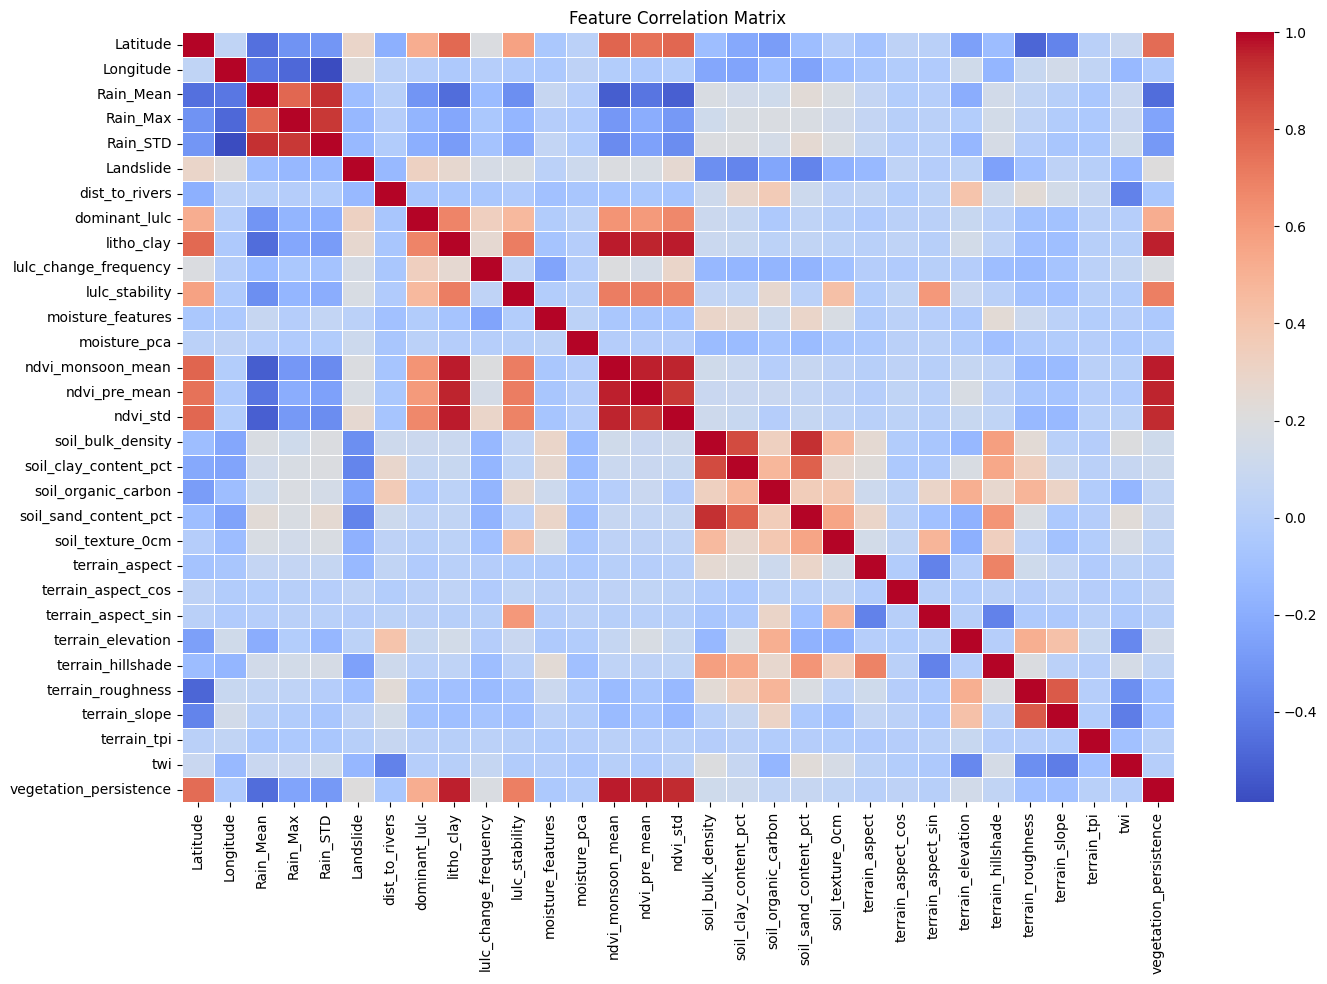

'\n1.No strong correlations between features, which is good for modeling.\n2. some features share multicollinearity.(ndvi_pre_mean and ndvi_monsoon_mean,rain_max and ndvi_monsoon_mean, etc..)\n\n'

In [67]:
# Heatmap of feature correlations

plt.figure(figsize=(16,10))

sns.heatmap(
    df_clean.corr(numeric_only=True),
    cmap='coolwarm',
    linewidths=0.5
)

plt.title("Feature Correlation Matrix")

plt.show()

'''
1.No strong correlations between features, which is good for modeling.
2. some features share multicollinearity.(ndvi_pre_mean and ndvi_monsoon_mean,rain_max and ndvi_monsoon_mean, etc..)

'''

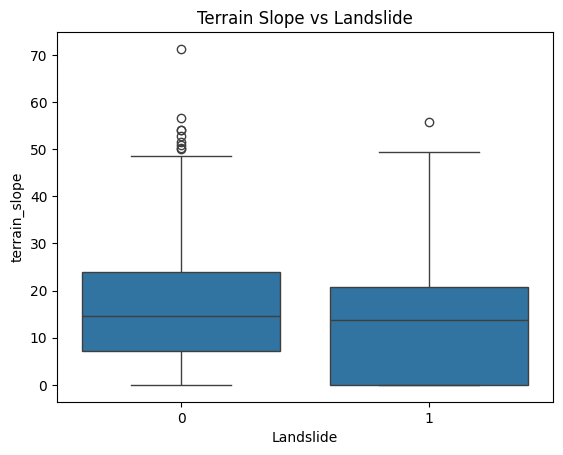

In [47]:
sns.boxplot(
    x='Landslide',
    y='terrain_slope',
    data=df_clean
)

plt.title("Terrain Slope vs Landslide")
plt.show()

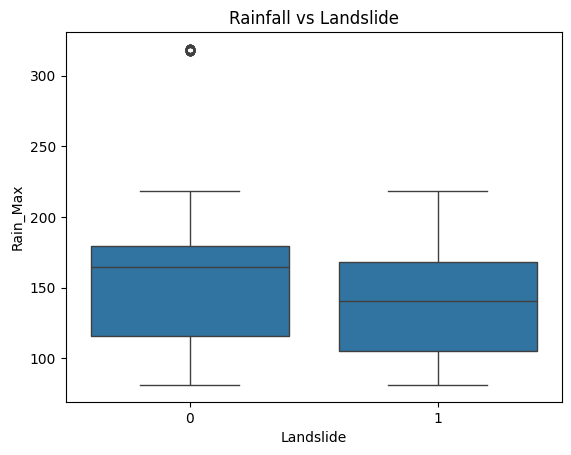

In [48]:
sns.boxplot(
    x='Landslide',
    y='Rain_Max',
    data=df_clean
)

plt.title("Rainfall vs Landslide")
plt.show()

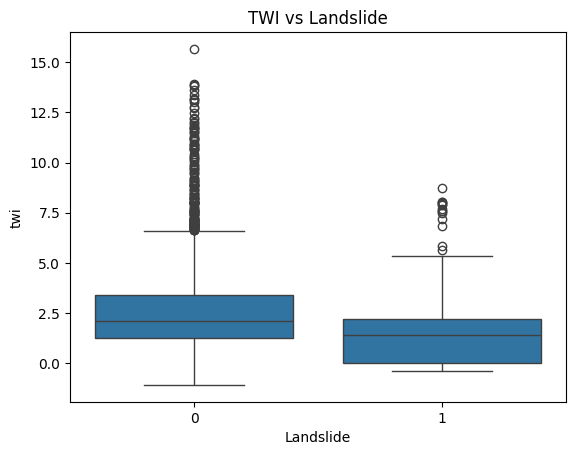

In [51]:
sns.boxplot(
    x='Landslide',
    y='twi',
    data=df_clean
)

plt.title("TWI vs Landslide")
plt.show()

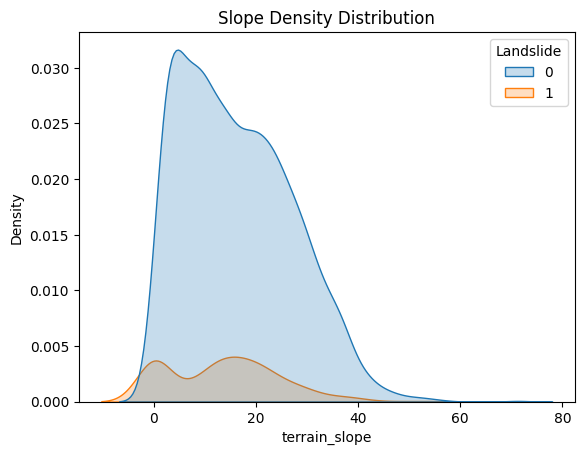

In [52]:
sns.kdeplot(
    data=df_clean,
    x='terrain_slope',
    hue='Landslide',
    fill=True
)

plt.title("Slope Density Distribution")
plt.show()

Random Forest-Based Feature Importance Analysis

Result : -
The Random Forest classifier was utilized to estimate feature importance
through impurity-based importance scoring, enabling identification
of influential variables contributing to landslide susceptibility modeling.

In [68]:
from sklearn.ensemble import RandomForestClassifier

X = df_clean.drop(columns=['Landslide'])
y = df_clean['Landslide']

rf = RandomForestClassifier()

rf.fit(X, y)

importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

print(importance.head(10))

              Feature  Importance
0            Latitude    0.099244
13      ndvi_pre_mean    0.095379
1           Longitude    0.087343
10  moisture_features    0.061074
28                twi    0.055441
12  ndvi_monsoon_mean    0.053912
5      dist_to_rivers    0.044304
25  terrain_roughness    0.042192
7          litho_clay    0.040298
23  terrain_elevation    0.036470


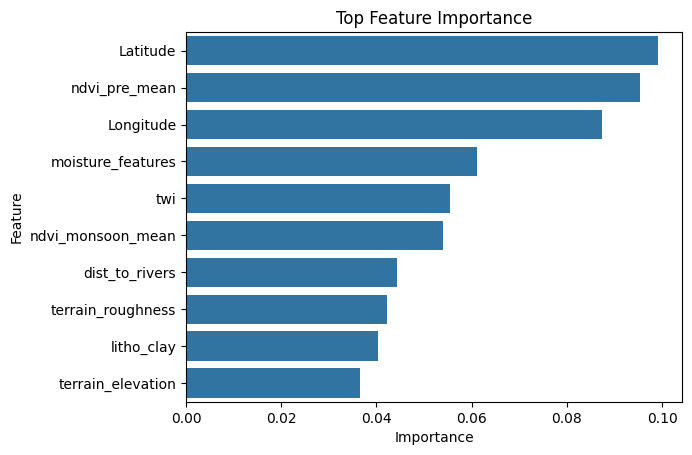

In [69]:
sns.barplot(
    x='Importance',
    y='Feature',
    data=importance.head(10)
)

plt.title("Top Feature Importance")
plt.show()

array([[<Axes: title={'center': 'Latitude'}>,
        <Axes: title={'center': 'Longitude'}>,
        <Axes: title={'center': 'Rain_Mean'}>,
        <Axes: title={'center': 'Rain_Max'}>,
        <Axes: title={'center': 'Rain_STD'}>,
        <Axes: title={'center': 'Landslide'}>],
       [<Axes: title={'center': 'dist_to_rivers'}>,
        <Axes: title={'center': 'dominant_lulc'}>,
        <Axes: title={'center': 'litho_clay'}>,
        <Axes: title={'center': 'lulc_change_frequency'}>,
        <Axes: title={'center': 'lulc_stability'}>,
        <Axes: title={'center': 'moisture_features'}>],
       [<Axes: title={'center': 'moisture_pca'}>,
        <Axes: title={'center': 'ndvi_monsoon_mean'}>,
        <Axes: title={'center': 'ndvi_pre_mean'}>,
        <Axes: title={'center': 'ndvi_std'}>,
        <Axes: title={'center': 'soil_bulk_density'}>,
        <Axes: title={'center': 'soil_clay_content_pct'}>],
       [<Axes: title={'center': 'soil_organic_carbon'}>,
        <Axes: title={'cente

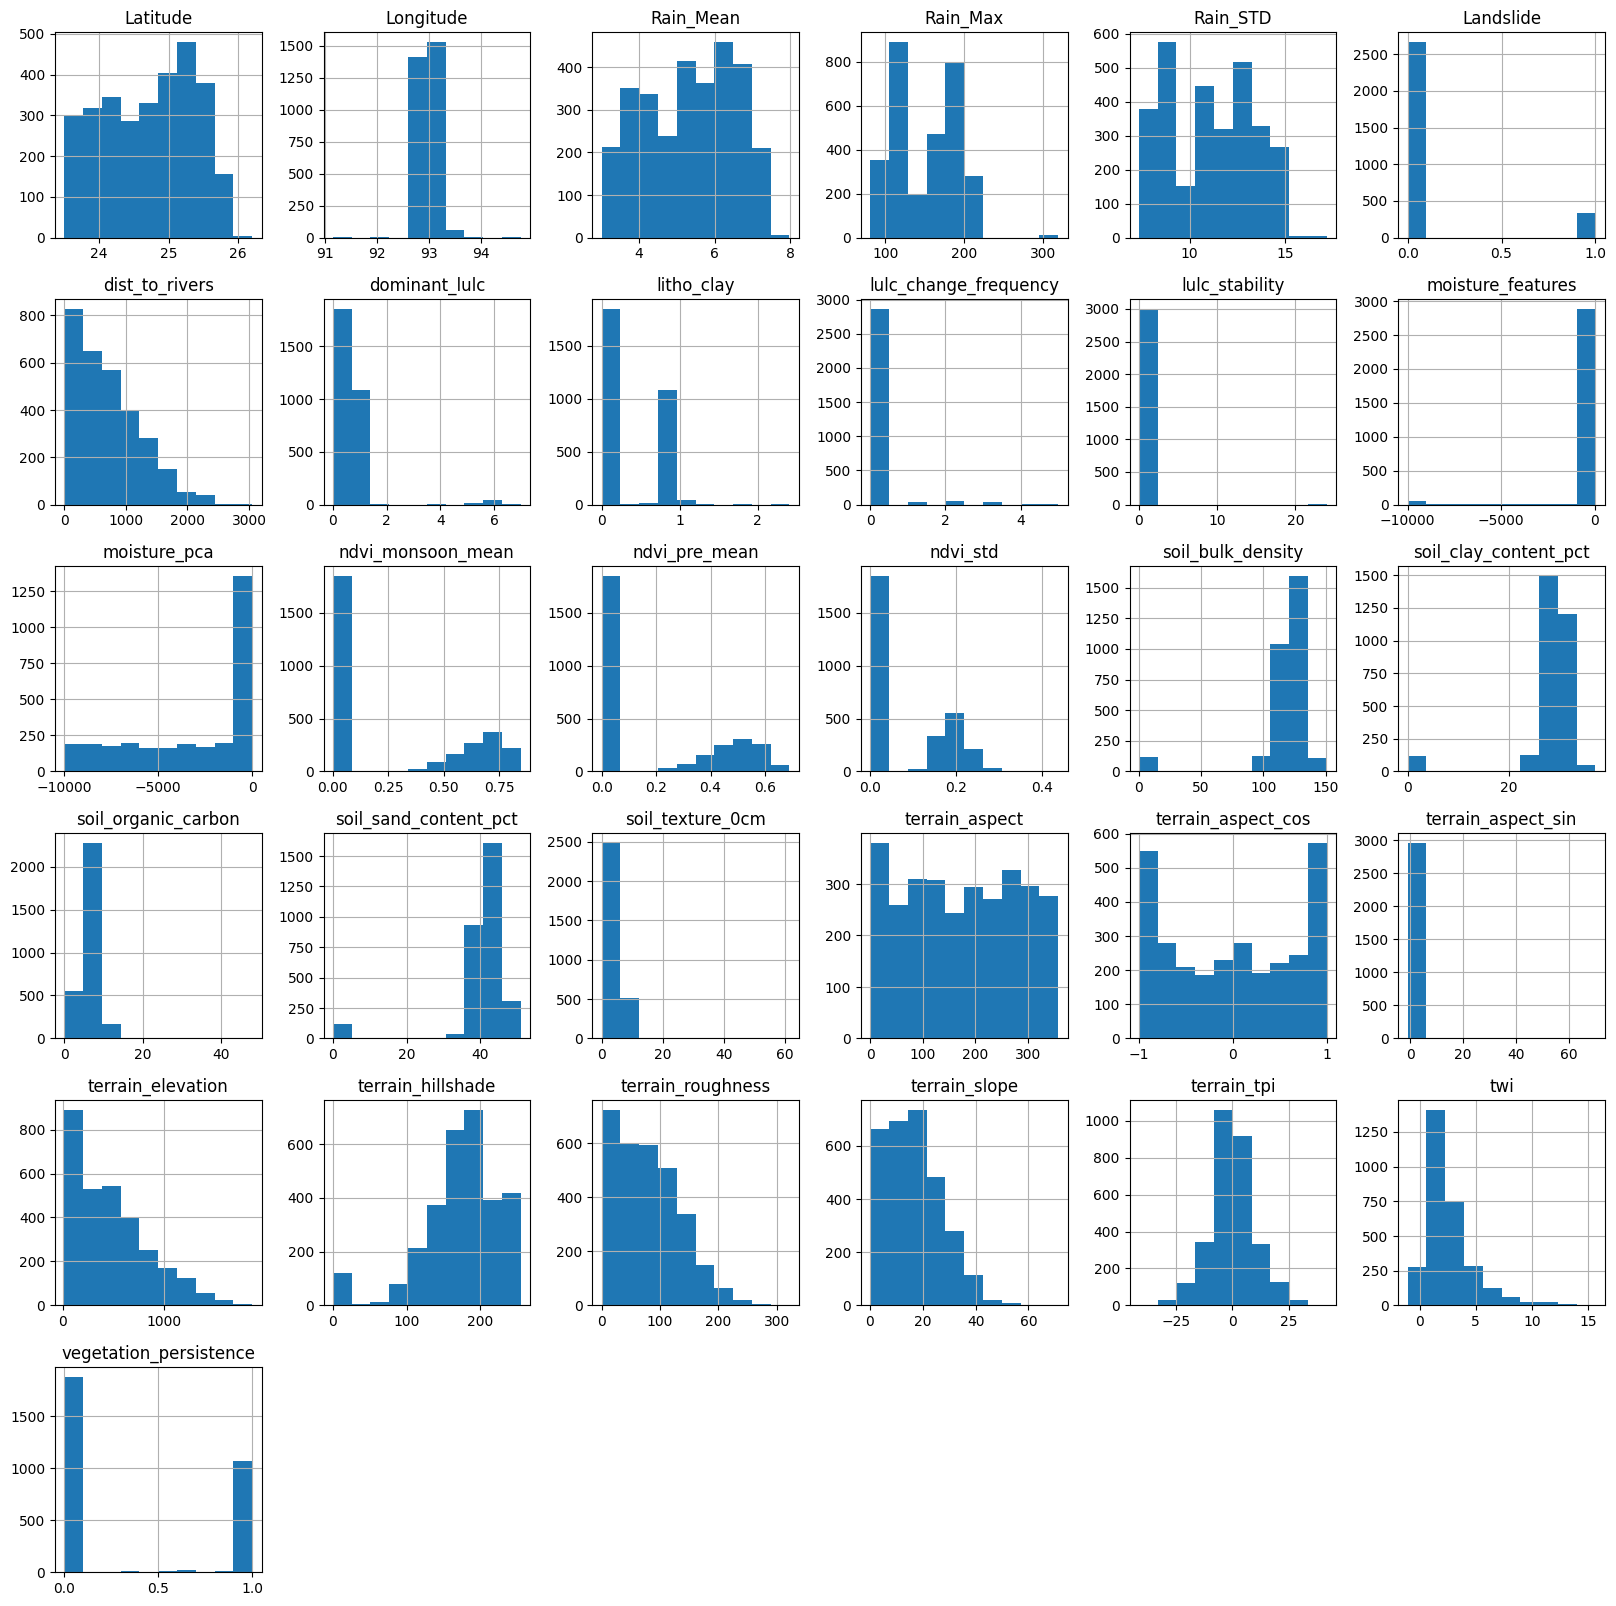

In [70]:
df_clean.hist(figsize=(20,20))

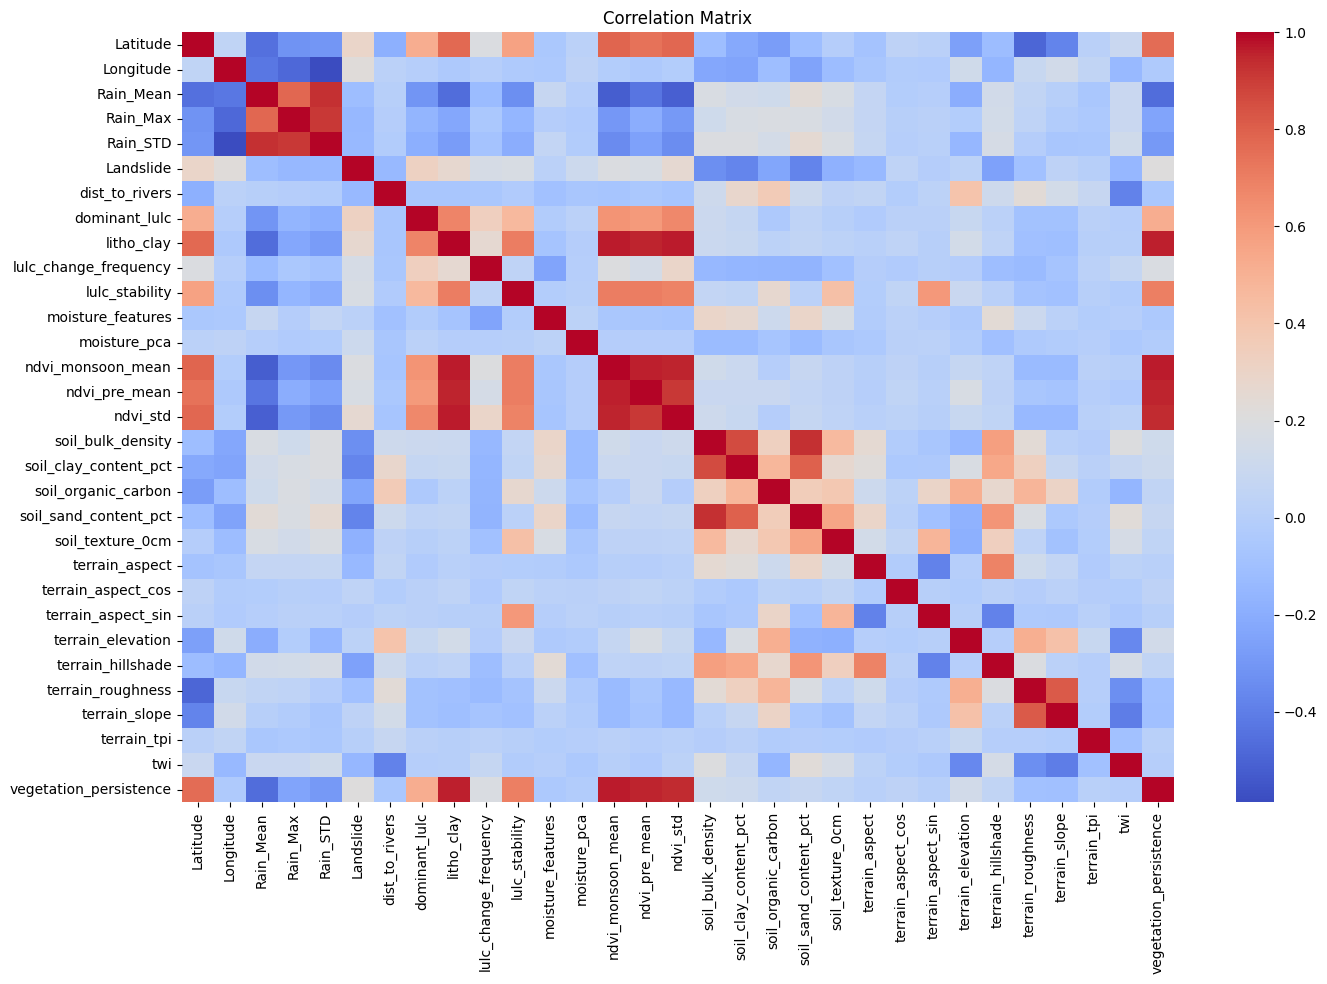

"'\n1. NO major correlation between features and target variable\n2. Some features have high correlation with each other, which may lead to multicollinearity issues in modeling. \n3. Consider feature selection or dimensionality reduction techniques.\n\n"

In [71]:
corr = df_clean.corr(numeric_only=True)

plt.figure(figsize=(16,10))
sns.heatmap(corr, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

''''
1. NO major correlation between features and target variable
2. Some features have high correlation with each other, which may lead to multicollinearity issues in modeling. 
3. Consider feature selection or dimensionality reduction techniques.

'''

# SPATIAL BLOCKS

If normal random train-test split is used:

1.Nearby pixels may enter both train and test sets,model memorizes neighboring terrain patterns
evaluation accuracy becomes artificially high.

This method help in :-
1.Reduce spatial leakage
2.Improve model generalization
3.Create more realistic evaluation performance

In [106]:

# Check coordinate columns
print(df_clean[['Latitude', 'Longitude']].head())

# Create latitude block
# Multiplying by 10 groups nearby coordinates together

# df_clean['lat_block'] = (
#     df_clean['Latitude'] * 10
# ).astype(int)

# # Create longitude block

# df_clean['lon_block'] = (
#     df_clean['Longitude'] * 10
# ).astype(int)



df_clean['lat_block'] = (
    df_clean['Latitude'] * 5
).astype(int)

df_clean['lon_block'] = (
    df_clean['Longitude'] * 5
).astype(int)

# Combine latitude and longitude blocks
# to create unique spatial regions

df_clean['spatial_group'] = (
    df_clean['lat_block'].astype(str)
    + "_"
    + df_clean['lon_block'].astype(str)
)

# Preview created groups

print(
    df_clean[
        [
            'Latitude',
            'Longitude',
            'lat_block',
            'lon_block',
            'spatial_group'
        ]
    ].head()
)

    Latitude  Longitude
0  25.636886  93.080398
1  23.561283  93.075403
2  24.110178  92.914018
3  25.394111  93.410417
4  25.357772  93.226611
    Latitude  Longitude  lat_block  lon_block spatial_group
0  25.636886  93.080398        128        465       128_465
1  23.561283  93.075403        117        465       117_465
2  24.110178  92.914018        120        464       120_464
3  25.394111  93.410417        126        467       126_467
4  25.357772  93.226611        126        466       126_466


Why we are using this .

1.Spatial block grouping was implemented using latitude and longitude coordinates to reduce spatial autocorrelation leakage.
2.Nearby geographic samples were grouped into common spatial regions,ensuring more reliable and realistic train-test separation for landslide susceptibility modeling.

# Feature and Target Split 


* Here droping the columns 

1. These contain direct location information , model may memorize geographic positions
this creates location-based leakage reduces true generalization ability.

In [107]:
# Define Feature Matrix (X) 

X = df_clean.drop(columns=[

    # Target column
    'Landslide',
    
    'Latitude',
    'Longitude',
    'lat_block',# Spatial grouping columns
    'lon_block',
    'spatial_group'
])


In [108]:
# Define Target Variable (y)

y = df_clean['Landslide']


In [109]:
#  Check Shapes

print("Feature Shape :", X.shape)
print("Target Shape  :", y.shape)


Feature Shape : (3000, 28)
Target Shape  : (3000,)


In [110]:
# Preview Features

print("\nFeature Columns:\n")

print(X.columns)

# Preview Target Distribution

print("\nTarget Distribution:\n")

print(y.value_counts())


Feature Columns:

Index(['Rain_Mean', 'Rain_Max', 'Rain_STD', 'dist_to_rivers', 'dominant_lulc',
       'litho_clay', 'lulc_change_frequency', 'lulc_stability',
       'moisture_features', 'moisture_pca', 'ndvi_monsoon_mean',
       'ndvi_pre_mean', 'ndvi_std', 'soil_bulk_density',
       'soil_clay_content_pct', 'soil_organic_carbon', 'soil_sand_content_pct',
       'soil_texture_0cm', 'terrain_aspect', 'terrain_aspect_cos',
       'terrain_aspect_sin', 'terrain_elevation', 'terrain_hillshade',
       'terrain_roughness', 'terrain_slope', 'terrain_tpi', 'twi',
       'vegetation_persistence'],
      dtype='str')

Target Distribution:

Landslide
0    2666
1     334
Name: count, dtype: int64


# Train and test split

* Normal random splitting is not reliable for geospatial datasets because nearby locations often contain highly similar terrain and environmental characteristics.

* So , we using Spatial Train-Test Split Using Spatial Blocks.

* what it does is :- 
    1. Reduce spatial autocorrelation leakage
    2. Avoid terrain memorization
    3. Improve real-world model generalization


In [111]:
from sklearn.model_selection import GroupShuffleSplit

# Initialize spatial group split

gss = GroupShuffleSplit(
    n_splits=1,
    test_size=0.2,
    random_state=42
)

# Perform split using spatial groups

train_idx, test_idx = next(
    gss.split(
        X,
        y,
        groups=df_clean['spatial_group']
    )
)

# Create training and testing datasets

X_train = X.iloc[train_idx]
X_test  = X.iloc[test_idx]

y_train = y.iloc[train_idx]
y_test  = y.iloc[test_idx]

# Check shapes

print("X_train Shape :", X_train.shape)
print("X_test Shape  :", X_test.shape)

print("y_train Shape :", y_train.shape)
print("y_test Shape  :", y_test.shape)

X_train Shape : (2378, 28)
X_test Shape  : (622, 28)
y_train Shape : (2378,)
y_test Shape  : (622,)


In [112]:
## Checking the class distribution in train and test sets to ensure representativeness

print("Training Class Distribution:\\n")
print(y_train.value_counts())

print("\\nTesting Class Distribution:\\n")
print(y_test.value_counts())

Training Class Distribution:\n
Landslide
0    2077
1     301
Name: count, dtype: int64
\nTesting Class Distribution:\n
Landslide
0    589
1     33
Name: count, dtype: int64


In [113]:
# Checking for Spatial Group Separation
# it help us  confirms no shared spatial blocks and reduced spatial leakage

train_groups = set(
    df_clean.iloc[train_idx]['spatial_group']
)

test_groups = set(
    df_clean.iloc[test_idx]['spatial_group']
)

common_groups = train_groups.intersection(test_groups)

print("Common Spatial Groups :", len(common_groups))

Common Spatial Groups : 0


# Handling Class Imbalance Using SMOTE

In [114]:
# Check missing values in training data

missing_values = X_train.isnull().sum()

# Show only columns having missing values

missing_values = missing_values[
    missing_values > 0
]

print(missing_values)

Series([], dtype: int64)


In [115]:
from imblearn.over_sampling import SMOTE


smote = SMOTE(
    random_state=42
)

# Apply SMOTE ONLY on training data

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

# Check shapes

print("Original X_train Shape :", X_train.shape)
print("SMOTE X_train Shape   :", X_train_smote.shape)

print("\\nOriginal y_train Distribution:\\n")
print(y_train.value_counts())

print("\\nSMOTE y_train Distribution:\\n")
print(y_train_smote.value_counts())

Original X_train Shape : (2378, 28)
SMOTE X_train Shape   : (4154, 28)
\nOriginal y_train Distribution:\n
Landslide
0    2077
1     301
Name: count, dtype: int64
\nSMOTE y_train Distribution:\n
Landslide
0    2077
1    2077
Name: count, dtype: int64


# Model Trainig

## Base model initialization


In [ ]:
# Random Forest Classifier
rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

# XGBoost Classifier
xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.05,
    random_state=42,
    eval_metric='logloss'
)

# LightGBM Classifier
lgbm_model = LGBMClassifier(
    n_estimators=200,
    learning_rate=0.05,
    random_state=42
)

# CatBoost Classifier
cat_model = CatBoostClassifier(
    iterations=200,
    learning_rate=0.05,
    depth=6,
    verbose=0,
    random_state=42
)

## Individual model Training

In [117]:
# Random Forest
rf_model.fit(
    X_train_smote,
    y_train_smote
)

# XGBoost
xgb_model.fit(
    X_train_smote,
    y_train_smote
)

# LightGBM
lgbm_model.fit(
    X_train_smote,
    y_train_smote
)

# CatBoost
cat_model.fit(
    X_train_smote,
    y_train_smote
)

[LightGBM] [Info] Number of positive: 2077, number of negative: 2077
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000602 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 5650
[LightGBM] [Info] Number of data points in the train set: 4154, number of used features: 28
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000


CatBoostClassifier(depth=6, iterations=200, learning_rate=0.05, random_state=42, verbose=0)

## Model EVALUATION

In [118]:
def evaluate_model(model, X_test, y_test, model_name):

    # Predictions
    y_pred = model.predict(X_test)

    # Probability predictions
    y_prob = model.predict_proba(X_test)[:, 1]

    # Metrics
    accuracy = accuracy_score(y_test, y_pred)

    precision = precision_score(y_test, y_pred)

    recall = recall_score(y_test, y_pred)

    f1 = f1_score(y_test, y_pred)

    roc_auc = roc_auc_score(y_test, y_prob)

    # Print Results
    print(f"\\n========== {model_name} ==========")

    print("Accuracy :", round(accuracy, 4))

    print("Precision:", round(precision, 4))

    print("Recall   :", round(recall, 4))

    print("F1 Score :", round(f1, 4))

    print("ROC AUC  :", round(roc_auc, 4))

    print("\\nConfusion Matrix:\\n")

    print(confusion_matrix(y_test, y_pred))

    print("\\nClassification Report:\\n")

    print(classification_report(y_test, y_pred))

    return {
        'Model': model_name,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1 Score': f1,
        'ROC AUC': roc_auc
    }

## Resluts 

In [119]:
results = []

results.append(
    evaluate_model(
        rf_model,
        X_test,
        y_test,
        "Random Forest"
    )
)

results.append(
    evaluate_model(
        xgb_model,
        X_test,
        y_test,
        "XGBoost"
    )
)

results.append(
    evaluate_model(
        lgbm_model,
        X_test,
        y_test,
        "LightGBM"
    )
)

results.append(
    evaluate_model(
        cat_model,
        X_test,
        y_test,
        "CatBoost"
    )
)

\n========== Random Forest ==========
Accuracy : 0.9646
Precision: 0.7895
Recall   : 0.4545
F1 Score : 0.5769
ROC AUC  : 0.9622
\nConfusion Matrix:\n
[[585   4]
 [ 18  15]]
\nClassification Report:\n
              precision    recall  f1-score   support

           0       0.97      0.99      0.98       589
           1       0.79      0.45      0.58        33

    accuracy                           0.96       622
   macro avg       0.88      0.72      0.78       622
weighted avg       0.96      0.96      0.96       622

\n========== XGBoost ==========
Accuracy : 0.9646
Precision: 0.7619
Recall   : 0.4848
F1 Score : 0.5926
ROC AUC  : 0.9537
\nConfusion Matrix:\n
[[584   5]
 [ 17  16]]
\nClassification Report:\n
              precision    recall  f1-score   support

           0       0.97      0.99      0.98       589
           1       0.76      0.48      0.59        33

    accuracy                           0.96       622
   macro avg       0.87      0.74      0.79       622
weighte

In [120]:
results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by='ROC AUC',
    ascending=False
)

print(results_df)

           Model  Accuracy  Precision    Recall  F1 Score   ROC AUC
0  Random Forest  0.964630   0.789474  0.454545  0.576923  0.962160
3       CatBoost  0.967846   0.882353  0.454545  0.600000  0.961620
1        XGBoost  0.964630   0.761905  0.484848  0.592593  0.953697
2       LightGBM  0.983923   1.000000  0.696970  0.821429  0.940371


# Hyperparameter Tuning and Regularization

In [ ]:
# BASE LIGHTGBM MODEL

lgbm_base = LGBMClassifier(
    
    random_state=42

)

In [123]:
# ============================================
# HYPERPARAMETER SEARCH SPACE
# ============================================

param_grid = {

    'n_estimators': [100, 150, 200, 300],

    'learning_rate': [0.01, 0.03, 0.05],

    'max_depth': [4, 5, 6, 7],

    'num_leaves': [15, 20, 31, 40],

    'subsample': [0.7, 0.8, 0.9],

    'colsample_bytree': [0.7, 0.8, 0.9],

    'min_child_samples': [10, 20, 30],

    'reg_alpha': [0, 0.1, 0.5, 1],

    'reg_lambda': [0, 0.1, 0.5, 1]

}

In [124]:
# ============================================
# RANDOMIZED SEARCH
# ============================================

random_search = RandomizedSearchCV(

    estimator=lgbm_base,

    param_distributions=param_grid,

    n_iter=20,

    scoring='roc_auc',

    cv=3,

    verbose=2,

    random_state=42,

    n_jobs=-1

)

In [125]:
# ============================================
# FIT RANDOMIZED SEARCH
# ============================================

random_search.fit(

    X_train_smote,
    y_train_smote

)

Fitting 3 folds for each of 20 candidates, totalling 60 fits
[LightGBM] [Info] Number of positive: 2077, number of negative: 2077
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000527 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 5650
[LightGBM] [Info] Number of data points in the train set: 4154, number of used features: 28
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive 

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LGBMClassifie...ndom_state=42)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'colsample_bytree': [0.7, 0.8, ...], 'learning_rate': [0.01, 0.03, ...], 'max_depth': [4, 5, ...], 'min_child_samples': [10, 20, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",20
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be u

In [126]:
# ============================================
# BEST PARAMETERS
# ============================================

print("Best Parameters:\\n")

print(random_search.best_params_)

Best Parameters:\n
{'subsample': 0.7, 'reg_lambda': 0.5, 'reg_alpha': 0.1, 'num_leaves': 15, 'n_estimators': 150, 'min_child_samples': 30, 'max_depth': 7, 'learning_rate': 0.05, 'colsample_bytree': 0.9}


In [127]:
# ============================================
# BEST TUNED MODEL
# ============================================

best_lgbm = random_search.best_estimator_

In [128]:
# ============================================
# PREDICTIONS
# ============================================

y_pred = best_lgbm.predict(X_test)

y_prob = best_lgbm.predict_proba(X_test)[:, 1]

# ============================================
# METRICS
# ============================================

from sklearn.metrics import (

    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report

)

accuracy = accuracy_score(
    y_test,
    y_pred
)

precision = precision_score(
    y_test,
    y_pred
)

recall = recall_score(
    y_test,
    y_pred
)

f1 = f1_score(
    y_test,
    y_pred
)

roc_auc = roc_auc_score(
    y_test,
    y_prob
)

# ============================================
# RESULTS
# ============================================

print("\n===== Tuned LightGBM Results =====")

print("Accuracy :", round(accuracy, 4))

print("Precision:", round(precision, 4))

print("Recall   :", round(recall, 4))

print("F1 Score :", round(f1, 4))

print("ROC AUC  :", round(roc_auc, 4))

print("\nConfusion Matrix:\n")

print(confusion_matrix(
    y_test,
    y_pred
))

print("\nClassification Report:\n")

print(classification_report(
    y_test,
    y_pred
))


===== Tuned LightGBM Results =====
Accuracy : 0.9759
Precision: 0.875
Recall   : 0.6364
F1 Score : 0.7368
ROC AUC  : 0.972

Confusion Matrix:

[[586   3]
 [ 12  21]]

Classification Report:

              precision    recall  f1-score   support

           0       0.98      0.99      0.99       589
           1       0.88      0.64      0.74        33

    accuracy                           0.98       622
   macro avg       0.93      0.82      0.86       622
weighted avg       0.97      0.98      0.97       622



In [129]:
# ============================================
# SAVE TUNED MODEL
# ============================================

import joblib

joblib.dump(

    best_lgbm,
    "tuned_lightgbm_model.pkl"

)

print("Tuned Model Saved Successfully")

Tuned Model Saved Successfully


## Best Model Selection

# Ensemble Model Construction

In [131]:
# ============================================
# SOFT VOTING ENSEMBLE MODEL
# ============================================

ensemble_model = VotingClassifier(

    estimators=[

        ('rf', rf_model),

        ('xgb', xgb_model),

        ('lgbm', best_lgbm),

        ('cat', cat_model)

    ],

    voting='soft',

    n_jobs=-1

)

In [132]:
# ============================================
# TRAIN ENSEMBLE MODEL
# ============================================

ensemble_model.fit(

    X_train_smote,
    y_train_smote

)

print("Ensemble Model Trained Successfully")

Ensemble Model Trained Successfully


In [133]:
# ============================================
# ENSEMBLE MODEL EVALUATION
# ============================================

ensemble_results = evaluate_model(

    ensemble_model,

    X_test,

    y_test,

    "Voting Ensemble"

)

\n========== Voting Ensemble ==========
Accuracy : 0.9695
Precision: 0.8889
Recall   : 0.4848
F1 Score : 0.6275
ROC AUC  : 0.9703
\nConfusion Matrix:\n
[[587   2]
 [ 17  16]]
\nClassification Report:\n
              precision    recall  f1-score   support

           0       0.97      1.00      0.98       589
           1       0.89      0.48      0.63        33

    accuracy                           0.97       622
   macro avg       0.93      0.74      0.81       622
weighted avg       0.97      0.97      0.97       622



In [134]:
# ============================================
# ADD ENSEMBLE RESULT
# ============================================

results.append(ensemble_results)

# ============================================
# CREATE COMPARISON TABLE
# ============================================

results_df = pd.DataFrame(results)

results_df = results_df.sort_values(

    by='ROC AUC',
    ascending=False

)

print(results_df)

             Model  Accuracy  Precision    Recall  F1 Score   ROC AUC
4  Voting Ensemble  0.969453   0.888889  0.484848  0.627451  0.970314
0    Random Forest  0.964630   0.789474  0.454545  0.576923  0.962160
3         CatBoost  0.967846   0.882353  0.454545  0.600000  0.961620
1          XGBoost  0.964630   0.761905  0.484848  0.592593  0.953697
2         LightGBM  0.983923   1.000000  0.696970  0.821429  0.940371


In [137]:
# ============================================
# SAVE FINAL ENSEMBLE MODEL
# ============================================

import joblib

joblib.dump(

    ensemble_model,

    "final_landslide_ensemble_model.pkl"

)

print("Final Ensemble Model Saved Successfully")

Final Ensemble Model Saved Successfully


## Ensemble Model Evaluation

# SHAP-Based Model Interpretability Analysis

In [139]:
# ============================================
# LOAD SAVED ENSEMBLE MODEL
# ============================================

loaded_ensemble_model = joblib.load(

    "final_landslide_ensemble_model.pkl"

)

print("Ensemble Model Loaded Successfully")

Ensemble Model Loaded Successfully


In [140]:
shap_model = lgbm_model

In [142]:
# ============================================
# CREATE SHAP EXPLAINER
# ============================================

explainer = shap.TreeExplainer(

    shap_model

)

print("SHAP Explainer Created Successfully")

SHAP Explainer Created Successfully


In [143]:
# ============================================
# GENERATE SHAP VALUES
# ============================================

shap_values = explainer.shap_values(

    X_test

)

c:\Users\Nageshwar\AppData\Local\Programs\Python\Python312\Lib\site-packages\shap\explainers\_tree.py:620: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


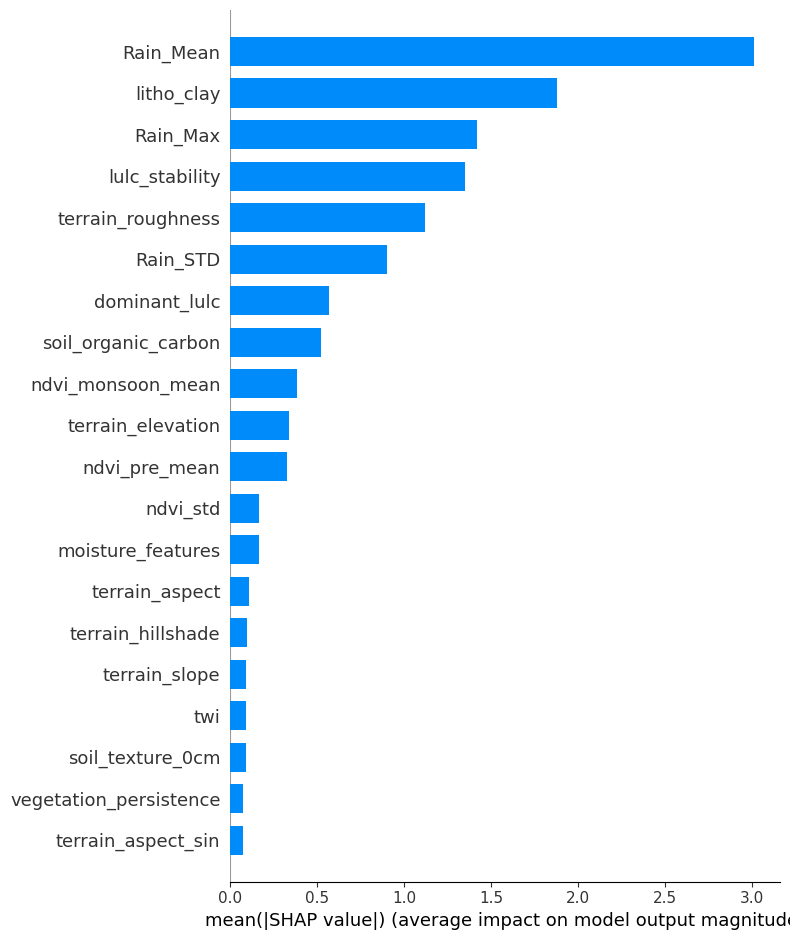

In [144]:
# ============================================
# SHAP GLOBAL FEATURE IMPORTANCE
# ============================================

shap.summary_plot(

    shap_values,

    X_test,

    plot_type='bar'

)

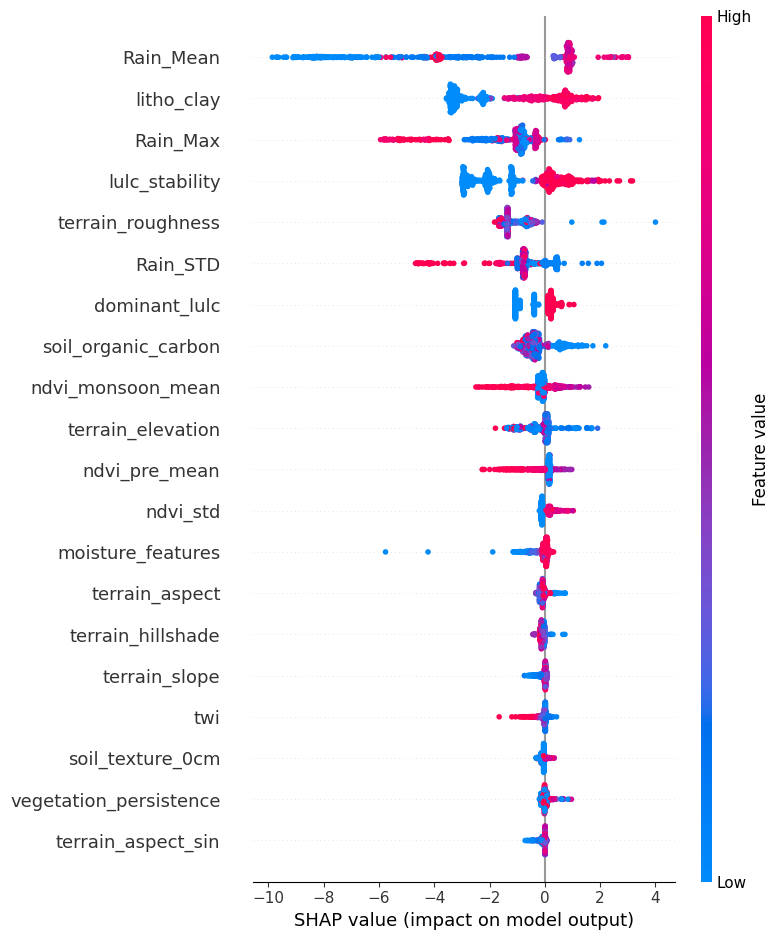

In [145]:
# ============================================
# SHAP DETAILED DISTRIBUTION PLOT
# ============================================

shap.summary_plot(

    shap_values,

    X_test

)

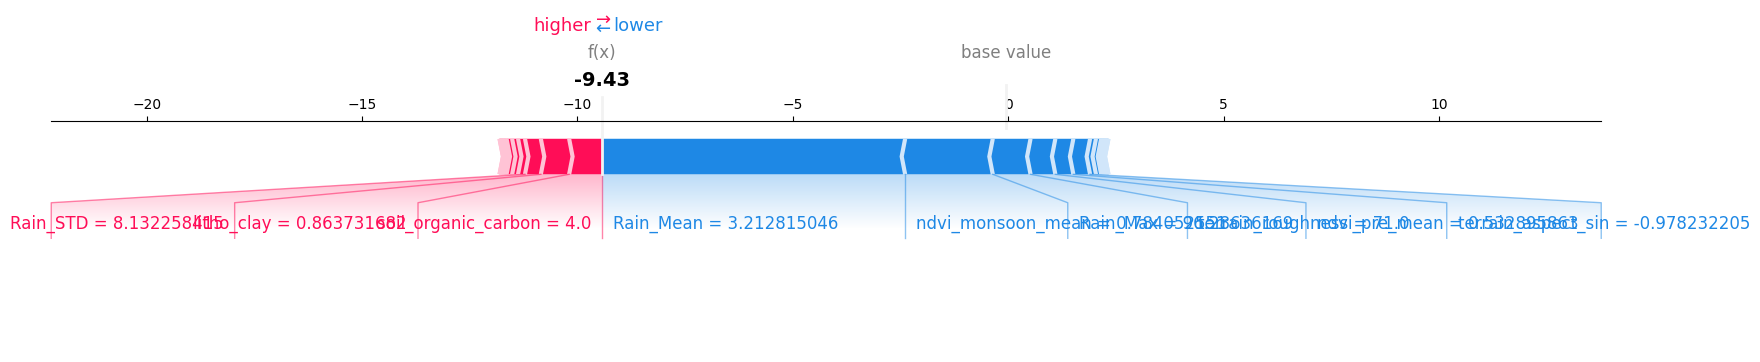

In [146]:
# ============================================
# SINGLE SAMPLE SHAP EXPLANATION
# ============================================

sample_index = 0

shap.force_plot(

    explainer.expected_value,

    shap_values[sample_index],

    X_test.iloc[sample_index],

    matplotlib=True

)

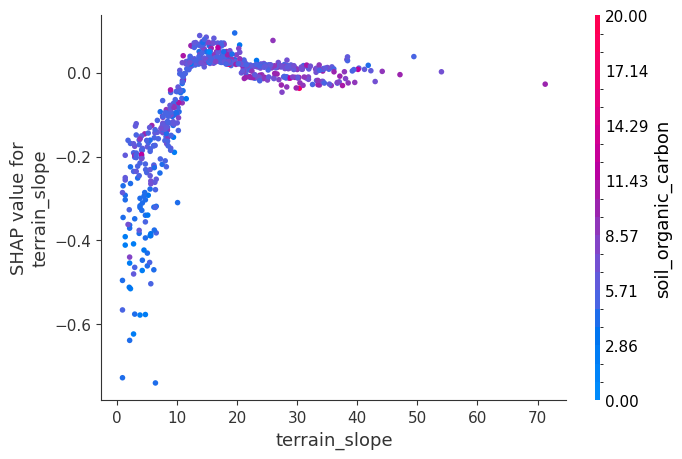

In [147]:
# ============================================
# TERRAIN SLOPE DEPENDENCE PLOT
# ============================================

shap.dependence_plot(

    'terrain_slope',

    shap_values,

    X_test

)

# Final Model Saving

In [148]:
# ============================================
# MODEL SAVING
# ============================================

import joblib

# Save Final Ensemble Model

joblib.dump(

    ensemble_model,

    "final_landslide_ensemble_model.pkl"

)

print("Final Ensemble Model Saved Successfully")

Final Ensemble Model Saved Successfully


## Saved Model Loading

In [149]:
# ============================================
# LOAD SAVED MODEL
# ============================================

loaded_model = joblib.load(

    "final_landslide_ensemble_model.pkl"

)

print("Model Loaded Successfully")

Model Loaded Successfully


# Single Sample Prediction Demonstration

In [150]:
# ============================================
# SELECT ONE TEST SAMPLE
# ============================================

sample = X_test.iloc[[0]]

# ============================================
# ACTUAL VALUE
# ============================================

actual_value = y_test.iloc[0]

# ============================================
# MODEL PREDICTION
# ============================================

prediction = loaded_model.predict(

    sample

)[0]

# ============================================
# PREDICTION PROBABILITY
# ============================================

probability = loaded_model.predict_proba(

    sample

)[0][1]

# ============================================
# RESULTS
# ============================================

print("Actual Value :", actual_value)

print("Predicted Value :", prediction)

print("Landslide Probability :",

      round(probability, 4))

Actual Value : 0
Predicted Value : 0
Landslide Probability : 0.0209


# Custom Geospatial Input Prediction


In [151]:
# ============================================
# CHECK FEATURE ORDER
# ============================================

print(X_train.columns.tolist())

['Rain_Mean', 'Rain_Max', 'Rain_STD', 'dist_to_rivers', 'dominant_lulc', 'litho_clay', 'lulc_change_frequency', 'lulc_stability', 'moisture_features', 'moisture_pca', 'ndvi_monsoon_mean', 'ndvi_pre_mean', 'ndvi_std', 'soil_bulk_density', 'soil_clay_content_pct', 'soil_organic_carbon', 'soil_sand_content_pct', 'soil_texture_0cm', 'terrain_aspect', 'terrain_aspect_cos', 'terrain_aspect_sin', 'terrain_elevation', 'terrain_hillshade', 'terrain_roughness', 'terrain_slope', 'terrain_tpi', 'twi', 'vegetation_persistence']


In [152]:
# ============================================
# CUSTOM SAMPLE INPUT
# ============================================

new_sample = pd.DataFrame([{

    'Rain_Mean': 160,
    'Rain_Max': 210,
    'Rain_STD': 25,

    'dist_to_rivers': 350,

    'dominant_lulc': 2,

    'litho_clay': 0.68,

    'lulc_change_frequency': 3,

    'lulc_stability': 0.55,

    'moisture_features': 0.61,

    'moisture_pca': 0.42,

    'ndvi_monsoon_mean': 0.58,

    'ndvi_pre_mean': 0.51,

    'ndvi_std': 0.14,

    'soil_bulk_density': 32,

    'soil_clay_content_pct': 41,

    'soil_organic_carbon': 12,

    'soil_sand_content_pct': 29,

    'soil_texture_0cm': 0.44,

    'terrain_aspect': 110,

    'terrain_aspect_cos': -0.34,

    'terrain_aspect_sin': 0.93,

    'terrain_elevation': 620,

    'terrain_hillshade': 185,

    'terrain_roughness': 0.71,

    'terrain_slope': 32,

    'terrain_tpi': 0.54,

    'twi': 7.2,

    'vegetation_persistence': 0.58

}])

# ============================================
# MODEL PREDICTION
# ============================================

prediction = loaded_model.predict(

    new_sample

)[0]

# ============================================
# PREDICTION PROBABILITY
# ============================================

probability = loaded_model.predict_proba(

    new_sample

)[0][1]

# ============================================
# OUTPUT
# ============================================

print("Predicted Class :", prediction)

print("Landslide Probability :",

      round(probability, 4))

Predicted Class : 0
Landslide Probability : 0.1021


In [155]:
high_risk_sample = pd.DataFrame([{

    'Rain_Mean': 280,
    'Rain_Max': 340,
    'Rain_STD': 60,

    'dist_to_rivers': 50,

    'dominant_lulc': 4,

    'litho_clay': 0.92,

    'lulc_change_frequency': 8,

    'lulc_stability': 0.18,

    'moisture_features': 0.88,

    'moisture_pca': 0.79,

    'ndvi_monsoon_mean': 0.84,

    'ndvi_pre_mean': 0.76,

    'ndvi_std': 0.42,

    'soil_bulk_density': 45,

    'soil_clay_content_pct': 62,

    'soil_organic_carbon': 22,

    'soil_sand_content_pct': 10,

    'soil_texture_0cm': 0.78,

    'terrain_aspect': 135,

    'terrain_aspect_cos': -0.70,

    'terrain_aspect_sin': 0.70,

    'terrain_elevation': 1450,

    'terrain_hillshade': 110,

    'terrain_roughness': 1.25,

    'terrain_slope': 48,

    'terrain_tpi': 1.12,

    'twi': 13.5,

    'vegetation_persistence': 0.20

}])

prediction = loaded_model.predict(
    high_risk_sample
)[0]

probability = loaded_model.predict_proba(
    high_risk_sample
)[0][1]

print("Predicted Class :", prediction)

print("Landslide Probability :",
      round(probability, 4))

Predicted Class : 0
Landslide Probability : 0.052


In [154]:
# ============================================
# FASTAPI IMPORTS
# ============================================

from fastapi import FastAPI

import pandas as pd

import joblib

# ============================================
# LOAD MODEL
# ============================================

model = joblib.load(

    "final_landslide_ensemble_model.pkl"

)

# ============================================
# INITIALIZE API
# ============================================

app = FastAPI()

# ============================================
# HOME ROUTE
# ============================================

@app.get("/")

def home():

    return {

        "message":
        "Landslide Susceptibility Prediction API"

    }

# ============================================
# PREDICTION ROUTE
# ============================================

@app.post("/predict")

def predict(data: dict):

    # Convert Input to DataFrame

    input_df = pd.DataFrame([data])

    # Prediction

    prediction = model.predict(

        input_df

    )[0]

    # Probability

    probability = model.predict_proba(

        input_df

    )[0][1]

    return {

        "prediction": int(prediction),

        "probability": float(probability)

    }